# Question 2 — Gamma Correction in L*a*b* Color Space
- (a) Apply gamma to the L plane and state γ
- (b) Show histograms before and after

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def show_color(img_bgr, title=''):
    plt.figure(figsize=(6, 5))
    plt.imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

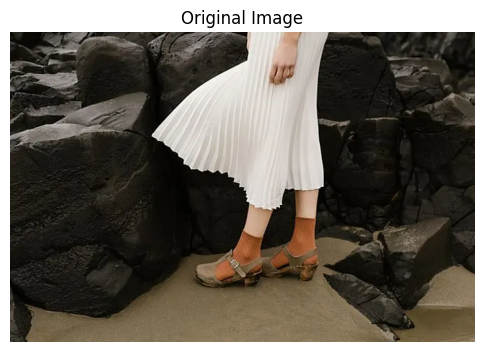

In [2]:
img = cv.imread('images/feet-shoes-rock.png')
assert img is not None
show_color(img, 'Original Image')

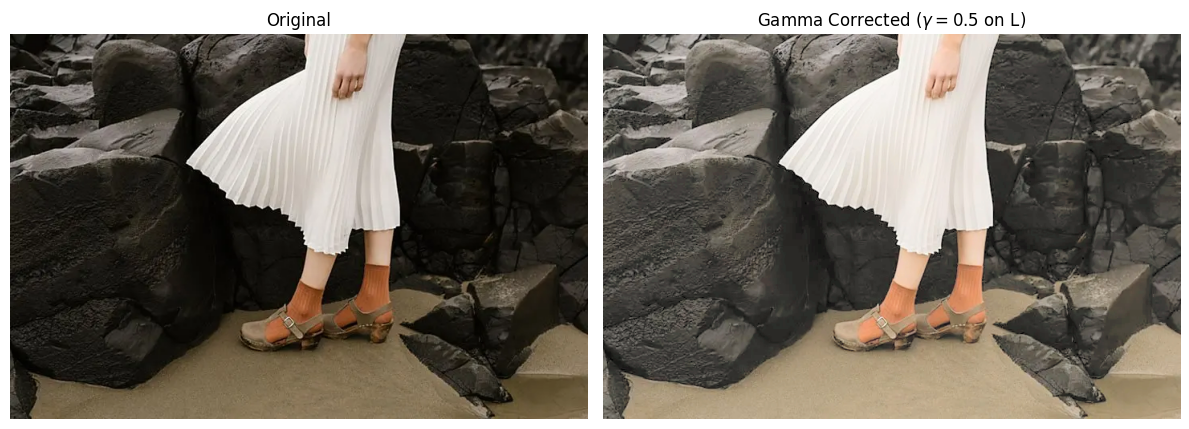

Gamma applied: γ = 0.5


In [3]:
# (a) Convert to L*a*b* and apply gamma to L channel only
# Why L*a*b*: L separates lightness from color — gamma on L adjusts
# brightness without shifting hues (unlike applying gamma to RGB directly)
# γ = 0.5 chosen to brighten the large dark rock regions
gamma = 0.5

lab = cv.cvtColor(img, cv.COLOR_BGR2Lab)
L, a, b = cv.split(lab)

L_corr = (np.power(L / 255.0, gamma) * 255).astype(np.uint8)

img_corr = cv.cvtColor(cv.merge([L_corr, a, b]), cv.COLOR_Lab2BGR)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cv.cvtColor(img_corr, cv.COLOR_BGR2RGB))
axes[1].set_title(rf'Gamma Corrected ($\gamma={gamma}$ on L)')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('outputs/q2a_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gamma applied: γ = {gamma}')

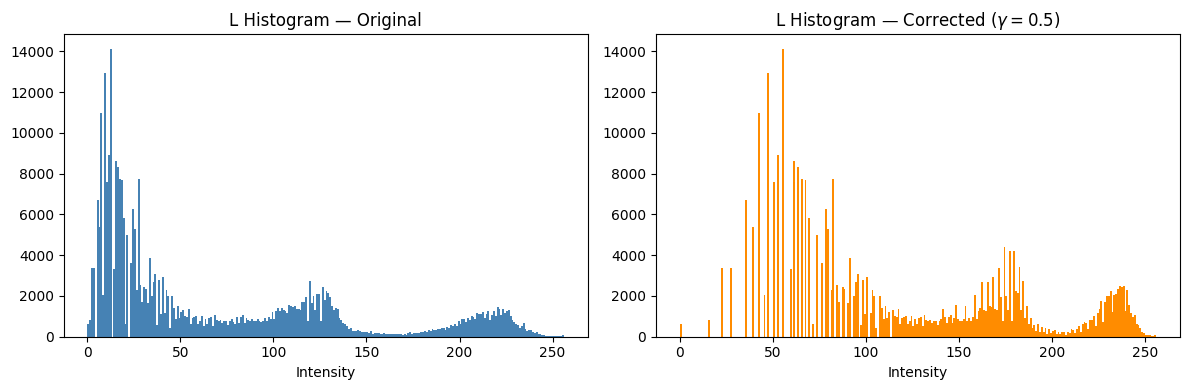

In [4]:
# (b) Histograms of L channel before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(L.ravel(),      bins=256, range=[0, 256], color='steelblue')
axes[0].set_title('L Histogram — Original')
axes[0].set_xlabel('Intensity')
axes[1].hist(L_corr.ravel(), bins=256, range=[0, 256], color='darkorange')
axes[1].set_title(rf'L Histogram — Corrected ($\gamma={gamma}$)')
axes[1].set_xlabel('Intensity')
plt.tight_layout()
plt.savefig('outputs/q2b_histograms.png', dpi=150, bbox_inches='tight')
plt.show()